In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/Reclamations_clean.csv")

In [ ]:
def clean_text(text):
    # Keep only letters (including French accents) and spaces
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text.lower())
    # Replace multiple spaces with a single space
    text = re.sub(r"\s+", " ", text)
    return text.strip()

texts = df["texte_reclamation"].dropna().apply(clean_text)

all_words = " ".join(texts).split()
word_counts = Counter(all_words)
print("Top 20 most common words:")
print(word_counts.most_common(20))

stopwords_fr = {
    "le", "la", "les", "de", "des", "du", "un", "une",
    "et", "ou", "en", "dans", "sur", "pour", "avec",
    "client", "demande", "réclamation", "incident",
    "lors", "pas", "ne", "se", "plus"
}

filtered_words = [w for w in all_words if w not in stopwords_fr]
filtered_counts = Counter(filtered_words)

print(filtered_counts.most_common(20))


[('d', 39697),
 ('signale', 20076),
 ('abonné', 19997),
 ('rapporte', 19997),
 ('assistance', 19855),
 ('image', 10112),
 ('figée', 10112),
 ('certaines', 10112),
 ('chaines', 10112),
 ('montant', 10066),
 ('facturé', 10066),
 ('incorrectement', 10066),
 ('régularisation', 10066),
 ('bruit', 10048),
 ('important', 10048),
 ('ligne', 10048),
 ('téléphonique', 10048),
 ('débit', 10034),
 ('très', 10034),
 ('faible', 10034)]

In [11]:
keywords = {
    "facturation": ["facturation", "facturé", "débit", "montant"],
    "installation": ["installation", "installer", "non réalisée"],
    "connexion": ["connexion", "authentification", "synchronise"],
    "internet_lent": ["lent", "faible", "débit"],
    "résiliation": ["résiliation", "contrat"],
    "modem": ["modem"],
}

keyword_counts = {}

for issue, words in keywords.items():
    keyword_counts[issue] = sum(
        texts.str.contains("|".join(words))
    )

keyword_counts

{'facturation': 30096,
 'installation': 10017,
 'connexion': 19805,
 'internet_lent': 10034,
 'résiliation': 19929,
 'modem': 9896}

In [ ]:
results = {}

for cat in df["category"].unique():
    cat_texts = (
        df[df["category"] == cat]["texte_reclamation"]
        .dropna()
        .str.lower()
    )
    results[cat] = sum(cat_texts.str.contains("factur"))

results

{'Coupure de ligne': 4491,
 'Résiliation': 1234,
 'Installation': 1981,
 'Facturation': 2328,
 'Internet lent': 4056,
 'Télévision': 2030,
 'Configuration': 785,
 'Autre': 385,
 'Assistance': 1562,
 'Problème matériel': 1210}

In [ ]:
urgency_issue = {}

for level in df["urgency"].unique():
    u_texts = (
        df[df["urgency"] == level]["texte_reclamation"]
        .dropna()
        .str.lower()
    )
    urgency_issue[level] = sum(u_texts.str.contains("factur"))

urgency_issue

{'Moyenne': 8064, 'Basse': 8040, 'élevée': 3019, 'Critique': 939}

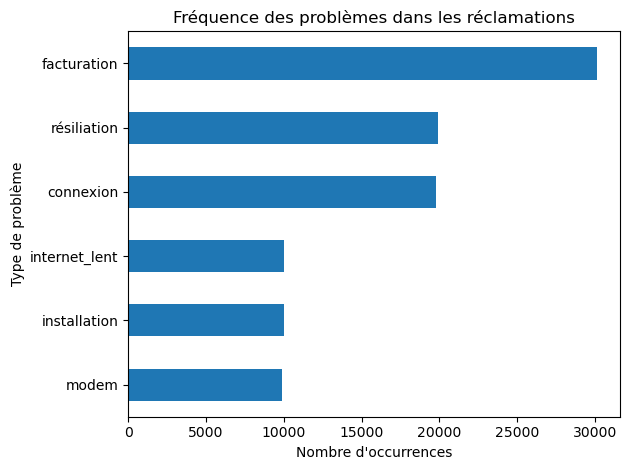

In [ ]:

pd.Series(keyword_counts).sort_values().plot(kind="barh")
plt.title("Fréquence des problèmes dans les réclamations")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Type de problème")
plt.tight_layout()
plt.show()